# Nghiên cứu thực nghiệm: Bộ phân lớp lọc cảnh báo sử dụng Lightweight Ontology cho hệ thống phát hiện xâm nhập mạng (AFC)

---

## SECTION 1: GIỚI THIỆU ĐỀ TÀI

### 1.1. Tổng quan bài toán phát hiện xâm nhập mạng (NIDS)
Trong kỷ nguyên số hóa và kết nối toàn cầu, an ninh mạng đã trở thành một trong những yếu tố sống còn của mọi tổ chức. Hệ thống phát hiện xâm nhập mạng (Network Intrusion Detection System - NIDS) đóng vai trò như một lớp lá chắn vòng ngoài, liên tục giám sát lưu lượng mạng để phát hiện các hành vi bất thường hoặc các cuộc tấn công đã biết. 

### 1.2. Vai trò của Bộ lọc cảnh báo (Alert Filtering)
Mặc dù NIDS rất quan trọng, các hệ thống truyền thống thường đối mặt với thách thức lớn về **tỷ lệ báo động giả (False Positives)** quá cao. Việc sinh ra hàng ngàn cảnh báo mỗi ngày gây ra hiện tượng "quá tải cảnh báo" (Alert Fatigue) cho các chuyên viên phân tích an ninh (SOC analysts). Bộ lọc cảnh báo (**Alert Filtering Classifier - AFC**) được phát triển nhằm mục đích phân loại, sàng lọc và giữ lại các cảnh báo thực sự nguy hiểm, loại bỏ nhiễu và báo động giả trước khi chuyển đến bước xử lý tiếp theo.

### 1.3. Phương pháp Lightweight Ontology
Để tối ưu hóa hiệu năng tính toán và khả năng phản ứng theo thời gian thực (Real-time), nghiên cứu này áp dụng phương pháp **Lightweight Ontology (Bản thể học rút gọn)**. Thay vì sử dụng toàn bộ tập đặc trưng lớn và phức tạp của lưu lượng mạng (như 80+ đặc trưng của CICIDS2017), chúng tôi ánh xạ và trích chọn ra **22 đặc trưng cốt lõi** dựa trên cấu trúc bản thể học mạng tối giản. Điều này giúp giảm đáng kể chi phí tính toán, bộ nhớ mà vẫn duy trì được ngữ nghĩa giàu có của luồng dữ liệu mạng.

### 1.4. Bộ dữ liệu CICIDS2017
Bộ dữ liệu **CICIDS2017** được cung cấp bởi Viện An ninh Mạng Canada (CIC), chứa lưu lượng mạng mô phỏng trong môi trường thực tế với đầy đủ các loại tấn công hiện đại (DDoS, Botnet, Web Attack, Infiltration, PortScan, Brute Force,...). 

### 1.5. Mục tiêu nghiên cứu
1. Huấn luyện và đánh giá hiệu năng của **8 thuật toán Học máy** khác nhau dựa trên tập dữ liệu đã áp dụng Lightweight Ontology.
2. So sánh toàn diện dựa trên các chỉ số: Accuracy, Precision, Recall, F1-score, ROC-AUC, thời gian huấn luyện và thời gian dự đoán.
3. Lựa chọn ra mô hình tối ưu nhất nhằm đóng gói thành bộ phân lớp lọc cảnh báo (AFC).

### 1.6. Quy trình nghiên cứu hệ thống
```
  [ CSV gốc (CICIDS2017) ] 
            │
            ▼
   preprocess_cicids.py   ──► (Xử lý nhiễu, Loại trùng, Trích chọn 22 đặc trưng Ontology)
            │
            ▼
 [ Lightweight Dataset ]  ──► (Lưu trữ dưới dạng .parquet trong data/lightweight/)
            │
            ▼
   [ Machine Learning ]   ──► (Notebook này: Đọc dữ liệu, EDA, Pipeline, Benchmark 8 mô hình)
            │
            ▼
     [ Best Model ]       ──► (Đánh giá chi tiết & Xuất mô hình tối ưu)
            │
            ▼
   [ Alert Filtering ]    ──► (Ứng dụng thực tế lọc cảnh báo mạng)
```

## SECTION 2: THIẾT LẬP THỰC NGHIỆM

* **Bộ dữ liệu thực nghiệm:** Tập dữ liệu thu gọn từ CICIDS2017, được phân rã thành các tệp định dạng `.parquet` (ví dụ: `Benign.parquet`, `Botnet.parquet`, `DDoS.parquet`,...) nhằm tối ưu tốc độ I/O.
* **Đặc trưng đầu vào:** **22 đặc trưng số và định danh** được tuyển chọn thông qua cấu trúc mạng của Lightweight Ontology.
* **Hình thức phân loại:** **Phân loại nhị phân (Binary Classification)**: 
    * `BENIGN` (Lưu lượng thông thường - Nhãn an toàn).
    * `ATTACK` (Lưu lượng tấn công - Cần lọc và giữ lại để xử lý).
* **Chiến lược phân rã dữ liệu:** Chia tập **Train/Test Split** theo tỷ lệ **80/20**, có áp dụng kỹ thuật `stratify` nhằm giữ nguyên tỷ lệ phân bố nhãn giữa tập huấn luyện và tập kiểm thử.
* **Chỉ số đánh giá chính:** `F1-score` và `Recall` được ưu tiên hàng đầu nhằm hạn chế tối đa việc bỏ sót các cuộc tấn công thực tế (`False Negatives`), đồng thời cân bằng với `Precision` để giảm báo động giả.
* **Môi trường thực nghiệm:** Ngôn ngữ lập trình Python 3.12+, thư viện Scikit-Learn thế hệ mới, chạy trên kiến trúc đa luồng tối ưu hóa thời gian huấn luyện.

In [1]:
# Chạy cell này nếu máy báo thiếu thư viện.
%pip install -r ../requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## SECTION 3: IMPORT THƯ VIỆN

In [2]:
import time
import json
import logging
import warnings
from pathlib import Path
from typing import Tuple, List, Dict, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import joblib

# Scikit-Learn Utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# ĐÃ THÊM TỪ KHÓA 'import' BỊ THIẾU Ở ĐÂY:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, roc_curve, precision_recall_curve
)

# Scikit-Learn Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, AdaBoostClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import LinearSVC

# Cấu hình ghi log
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
print("Hệ thống đã cập nhật bộ import thành công.")

Hệ thống đã cập nhật bộ import thành công.


## SECTION 4: CẤU HÌNH THỰC NGHIỆM

In [3]:
# Đường dẫn thư mục dựa trên cấu trúc dự án
DATA_DIR = Path("../data/parquet_lightweight")
MODEL_DIR = Path("../models")

# Tạo thư mục models tự động nếu chưa tồn tại
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Siêu tham số kiểm thử toàn cục
TEST_SIZE = 0.2
RANDOM_STATE = 42

print(f"Thư mục dữ liệu đầu vào: {DATA_DIR.resolve()}")
print(f"Thư mục lưu trữ mô hình: {MODEL_DIR.resolve()}")

Thư mục dữ liệu đầu vào: C:\Users\oggy2\OneDrive\Máy tính\Alert Filtering Classifier\data\parquet_lightweight
Thư mục lưu trữ mô hình: C:\Users\oggy2\OneDrive\Máy tính\Alert Filtering Classifier\models


## SECTION 5: ĐỌC VÀ CHUẨN HÓA DỮ LIỆU LIGHTWEIGHT

In [4]:
from pathlib import Path
from typing import Any

import logging

import pandas as pd
from tqdm.auto import tqdm


logger = logging.getLogger(__name__)


def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Chuẩn hóa tên cột.

    Chỉ loại bỏ khoảng trắng ở đầu và cuối tên cột.
    Giữ nguyên tên cột gốc của CICIDS2017 để đồng nhất
    với metadata và báo cáo nghiên cứu.
    """
    df = df.copy()
    df.columns = df.columns.str.strip()
    return df


def normalize_label(label: Any) -> str:
    """
    Chuyển bài toán đa lớp thành bài toán nhị phân.

    BENIGN  -> BENIGN
    Các nhãn còn lại -> ATTACK
    """

    label = str(label).strip().upper()

    if label == "BENIGN":
        return "BENIGN"

    return "ATTACK"


def read_one_parquet(file_path: Path) -> pd.DataFrame:
    """
    Đọc một file Parquet.

    Parameters
    ----------
    file_path : Path
        Đường dẫn tới file Parquet.

    Returns
    -------
    pd.DataFrame
        Dữ liệu đã đọc.
    """

    try:

        df = pd.read_parquet(file_path)

        df = normalize_columns(df)

        logger.info(
            "Đã đọc %-40s (%s dòng)",
            file_path.name,
            f"{len(df):,}",
        )

        return df

    except Exception as exc:

        raise RuntimeError(
            f"Không thể đọc file {file_path.name}"
        ) from exc


def load_lightweight_dataset(data_directory: Path) -> pd.DataFrame:
    """
    Đọc toàn bộ bộ dữ liệu Lightweight Ontology.

    Parameters
    ----------
    data_directory : Path
        Thư mục chứa các file Parquet.

    Returns
    -------
    pd.DataFrame
        DataFrame sau khi ghép toàn bộ dữ liệu.
    """

    if not data_directory.exists():
        raise FileNotFoundError(
            f"Không tìm thấy thư mục dữ liệu:\n{data_directory.resolve()}"
        )

    parquet_files = sorted(data_directory.glob("*.parquet"))

    if len(parquet_files) == 0:
        raise FileNotFoundError(
            f"Không tìm thấy file Parquet trong:\n{data_directory.resolve()}"
        )

    logger.info(
        "Tìm thấy %d file Parquet.",
        len(parquet_files),
    )

    frames = []

    for file in tqdm(
        parquet_files,
        desc="Đang đọc dữ liệu",
    ):

        frames.append(
            read_one_parquet(file)
        )

    data = pd.concat(
        frames,
        ignore_index=True,
    )

    if "Label" not in data.columns:
        raise KeyError(
            "Không tìm thấy cột 'Label' trong bộ dữ liệu."
        )

    # Chuyển bài toán đa lớp thành nhị phân
    data["Label"] = data["Label"].apply(
        normalize_label
    )

    logger.info("=" * 60)
    logger.info("THÔNG TIN BỘ DỮ LIỆU")
    logger.info("=" * 60)
    logger.info("Số lượng file      : %d", len(parquet_files))
    logger.info("Số lượng bản ghi   : %s", f"{len(data):,}")
    logger.info("Số lượng đặc trưng : %d", data.shape[1] - 1)
    logger.info("Số lượng lớp       : %d", data["Label"].nunique())

    logger.info("Phân bố nhãn:")

    for label, count in data["Label"].value_counts().items():

        logger.info(
            "  %-10s : %s",
            label,
            f"{count:,}",
        )

    logger.info("=" * 60)

    return data


# ============================================================
# THỰC THI
# ============================================================

# DATA_DIR phải được khai báo ở cell cấu hình
# Ví dụ:
# DATA_DIR = Path("data/lightweight")

df_raw = load_lightweight_dataset(DATA_DIR)

display(df_raw.head())

2026-07-23 20:52:39,756 - INFO - Tìm thấy 7 file Parquet.
Đang đọc dữ liệu:  14%|█▍        | 1/7 [00:12<01:13, 12.29s/it]2026-07-23 20:52:52,084 - INFO - Đã đọc Botnet-Friday-WorkingHours-Morning.pcap_ISCX.parquet (191,031 dòng)
2026-07-23 20:52:52,135 - INFO - Đã đọc Bruteforce-Tuesday-WorkingHours.pcap_ISCX.parquet (445,905 dòng)
2026-07-23 20:52:52,166 - INFO - Đã đọc DDoS-Friday-WorkingHours-Afternoon.pcap_ISCX.parquet (225,743 dòng)
Đang đọc dữ liệu:  57%|█████▋    | 4/7 [00:12<00:07,  2.36s/it]2026-07-23 20:52:52,284 - INFO - Đã đọc DoS-Wednesday-WorkingHours.pcap_ISCX.parquet (692,686 dòng)
2026-07-23 20:52:52,324 - INFO - Đã đọc Infiltration-Thursday-WorkingHours-Afternoon.pcap_ISCX.parquet (288,460 dòng)
2026-07-23 20:52:52,359 - INFO - Đã đọc Portscan-Friday-WorkingHours-Afternoon.pcap_ISCX.parquet (286,466 dòng)
Đang đọc dữ liệu: 100%|██████████| 7/7 [00:12<00:00,  1.80s/it]
2026-07-23 20:52:53,121 - INFO - ============================================================
2026-07

,Destination Port,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Flow Bytes/s,Flow Packets/s,SYN Flag Count,...,PSH Flag Count,URG Flag Count,Average Packet Size,Packet Length Mean,Packet Length Std,Init_Win_bytes_forward,Init_Win_bytes_backward,Active Mean,Idle Mean,Label
0,49188,6,4,2,0,12,0,3.000000e+06,5.000000e+05,0,...,0,1,9.000000,6.000000,0.000000,329,-1,0.0,0.0,BENIGN
1,49188,6,1,2,0,12,0,1.200000e+07,2.000000e+06,0,...,0,1,9.000000,6.000000,0.000000,329,-1,0.0,0.0,BENIGN
2,49486,6,3,2,0,12,0,4.000000e+06,6.666667e+05,0,...,0,1,9.000000,6.000000,0.000000,245,-1,0.0,0.0,BENIGN
3,49486,6,1,2,0,12,0,1.200000e+07,2.000000e+06,0,...,0,1,9.000000,6.000000,0.000000,245,-1,0.0,0.0,BENIGN
4,88,6,609,7,4,484,414,1.474548e+06,1.806240e+04,0,...,1,0,81.636364,74.833333,107.527445,8192,2053,0.0,0.0,BENIGN


## SECTION 6: KHÁM PHÁ DỮ LIỆU (EDA)

Dưới đây là các bước phân tích phân bố và đặc tính thống kê toán học của tập dữ liệu nghiên cứu.

In [5]:
print("--- 5 DÒNG DỮ LIỆU ĐẦU TIÊN ---")
display(df_raw.head())

print("\n--- THÔNG TIN CẤU TRÚC DỮ LIỆU ---")
df_raw.info()

print("\n--- THỐNG KÊ MÔ TẢ ĐẶC TRƯNG SỐ ---")
display(df_raw.describe().T)

print("\n--- KIỂM TRA GIÁ TRỊ THIẾU (MISSING VALUES) ---")
missing_counts = df_raw.isnull().sum()
print(missing_counts[missing_counts > 0] if missing_counts.sum() > 0 else "Không có giá trị thiếu nào.")

print("\n--- KIỂM TRA DÒNG TRÙNG LẶP ---")
dup_count = df_raw.duplicated().sum()
print(f"Số dòng trùng lặp còn lại: {dup_count} (Đã được tối ưu từ bước tiền xử lý)")

print("\n--- SỐ LƯỢNG BẢN GHI THEO NHÃN PHÂN LOẠI ---")
label_counts = df_raw['Label'].value_counts()
display(label_counts)

--- 5 DÒNG DỮ LIỆU ĐẦU TIÊN ---


,Destination Port,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Flow Bytes/s,Flow Packets/s,SYN Flag Count,...,PSH Flag Count,URG Flag Count,Average Packet Size,Packet Length Mean,Packet Length Std,Init_Win_bytes_forward,Init_Win_bytes_backward,Active Mean,Idle Mean,Label
0,49188,6,4,2,0,12,0,3.000000e+06,5.000000e+05,0,...,0,1,9.000000,6.000000,0.000000,329,-1,0.0,0.0,BENIGN
1,49188,6,1,2,0,12,0,1.200000e+07,2.000000e+06,0,...,0,1,9.000000,6.000000,0.000000,329,-1,0.0,0.0,BENIGN
2,49486,6,3,2,0,12,0,4.000000e+06,6.666667e+05,0,...,0,1,9.000000,6.000000,0.000000,245,-1,0.0,0.0,BENIGN
3,49486,6,1,2,0,12,0,1.200000e+07,2.000000e+06,0,...,0,1,9.000000,6.000000,0.000000,245,-1,0.0,0.0,BENIGN
4,88,6,609,7,4,484,414,1.474548e+06,1.806240e+04,0,...,1,0,81.636364,74.833333,107.527445,8192,2053,0.0,0.0,BENIGN



--- THÔNG TIN CẤU TRÚC DỮ LIỆU ---
<class 'pandas.DataFrame'>
RangeIndex: 2660168 entries, 0 to 2660167
Data columns (total 23 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Destination Port             int64  
 1   Protocol                     int64  
 2   Flow Duration                int64  
 3   Total Fwd Packets            int64  
 4   Total Backward Packets       int64  
 5   Total Length of Fwd Packets  int64  
 6   Total Length of Bwd Packets  int64  
 7   Flow Bytes/s                 float64
 8   Flow Packets/s               float64
 9   SYN Flag Count               int64  
 10  ACK Flag Count               int64  
 11  FIN Flag Count               int64  
 12  RST Flag Count               int64  
 13  PSH Flag Count               int64  
 14  URG Flag Count               int64  
 15  Average Packet Size          float64
 16  Packet Length Mean           float64
 17  Packet Length Std            float64
 18  Init_Win_bytes_fo

,count,mean,std,min,25%,50%,75%,max
Destination Port,2660168.0,8.081519e+03,1.828580e+04,0.0,53.000000,80.000000,4.430000e+02,6.553500e+04
Protocol,2660168.0,9.791348e+00,5.233559e+00,0.0,6.000000,6.000000,1.700000e+01,1.700000e+01
Flow Duration,2660168.0,1.493554e+07,3.375625e+07,-13.0,151.000000,31311.000000,3.395335e+06,1.200000e+08
Total Fwd Packets,2660168.0,8.992628e+00,7.192094e+02,1.0,2.000000,2.000000,5.000000e+00,2.197590e+05
Total Backward Packets,2660168.0,9.906031e+00,9.568314e+02,0.0,1.000000,2.000000,4.000000e+00,2.919220e+05
Total Length of Fwd Packets,2660168.0,5.488532e+02,1.012267e+04,0.0,6.000000,62.000000,1.960000e+02,1.290000e+07
Total Length of Bwd Packets,2660168.0,1.516043e+04,2.164000e+06,0.0,0.000000,122.000000,5.090000e+02,6.554530e+08
Flow Bytes/s,2660168.0,1.471189e+06,2.563683e+07,-193000000.0,119.194369,4568.146964,1.632653e+05,2.071000e+09
Flow Packets/s,2660168.0,7.175980e+04,2.557569e+05,-2000000.0,3.274382,111.144043,2.352941e+04,4.000000e+06
SYN Flag Count,2660168.0,4.656022e-02,2.106950e-01,0.0,0.000000,0.000000,0.000000e+00,1.000000e+00



--- KIỂM TRA GIÁ TRỊ THIẾU (MISSING VALUES) ---
Không có giá trị thiếu nào.

--- KIỂM TRA DÒNG TRÙNG LẶP ---
Số dòng trùng lặp còn lại: 462035 (Đã được tối ưu từ bước tiền xử lý)

--- SỐ LƯỢNG BẢN GHI THEO NHÃN PHÂN LOẠI ---


Label
BENIGN    2104703
ATTACK     555465
Name: count, dtype: int64

### 6.1. Biểu đồ phân bố nhãn lớp (Target Label Distribution)
Biểu đồ thể hiện mức độ cân bằng hoặc mất cân bằng giữa luồng dữ liệu sạch (`BENIGN`) và dữ liệu tấn công xâm nhập (`ATTACK`).

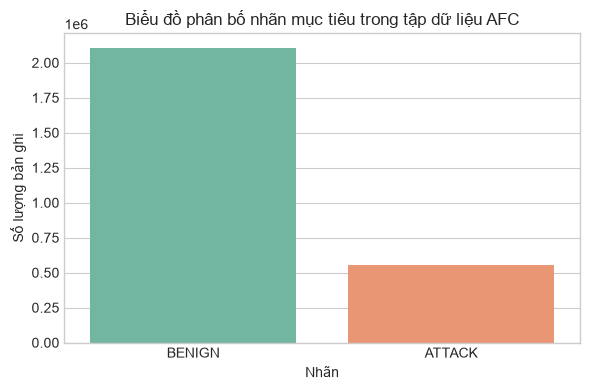

In [6]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Label', data=df_raw, palette='Set2')
plt.title("Biểu đồ phân bố nhãn mục tiêu trong tập dữ liệu AFC")
plt.xlabel("Nhãn")
plt.ylabel("Số lượng bản ghi")
plt.tight_layout()
plt.show()

**Nhận xét:** Biểu đồ phân bố nhãn cho thấy rõ ràng tương quan số lượng giữa lưu lượng bình thường và lưu lượng tấn công mạng. Sự chênh lệch này phản ánh đúng thực tế an ninh mạng (lưu lượng sạch luôn chiếm đa số). Việc sử dụng tham số `stratify` khi chia tập dữ liệu ở bước sau là vô cùng quan trọng để đảm bảo tính đại diện.

### 6.2. Biểu đồ Histogram của các đặc trưng tiêu biểu
Xem xét phân bố tần suất của 4 đặc trưng số đầu tiên để nhận diện hình dáng phân phối.

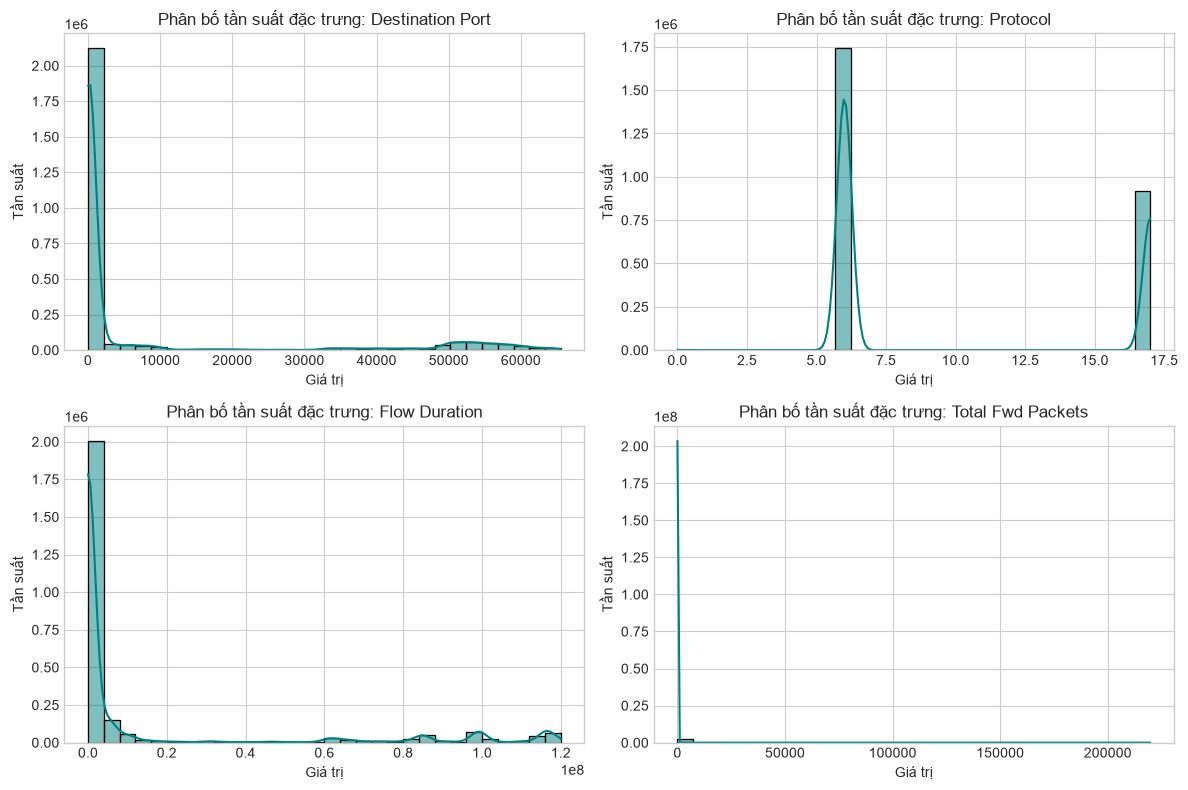

In [7]:
numeric_cols = df_raw.select_dtypes(include=[np.number]).columns.tolist()
features_to_plot = numeric_cols[:4] if len(numeric_cols) >= 4 else numeric_cols

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(features_to_plot):
    sns.histplot(df_raw[col], bins=30, kde=True, ax=axes[i], color='teal')
    axes[i].set_title(f"Phân bố tần suất đặc trưng: {col}")
    axes[i].set_xlabel("Giá trị")
    axes[i].set_ylabel("Tần suất")

plt.tight_layout()
plt.show()

**Nhận xét:** Hầu hết các đặc trưng mạng có phân phối lệch (skewed) rất mạnh, tập trung chủ yếu ở một vài dải giá trị cụ thể. Đặc tính này minh chứng rằng các mô hình dạng cây (Tree-based) sẽ có ưu thế hơn so với các mô hình tuyến tính vốn nhạy cảm với phân phối chuẩn.

### 6.3. Biểu đồ Ma trận tương quan (Correlation Heatmap)
Đo lường mối quan hệ tuyến tính giữa top 10 đặc trưng đầu tiên để nhận diện hiện tượng đa cộng tuyến.

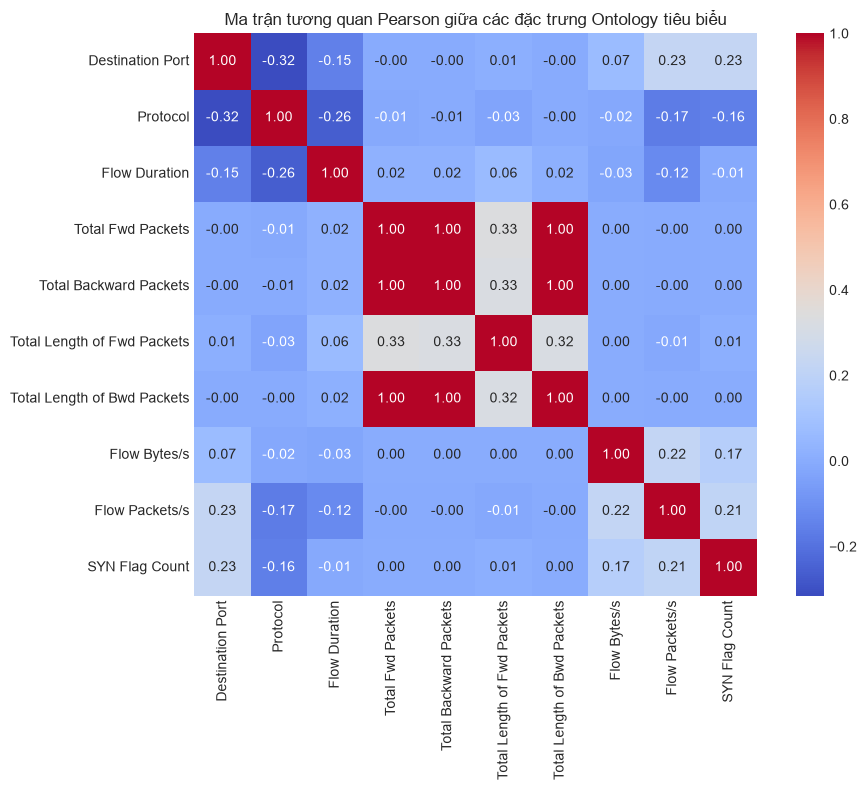

In [8]:
plt.figure(figsize=(10, 8))
top_corr_features = numeric_cols[:10]
corr_matrix = df_raw[top_corr_features].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title("Ma trận tương quan Pearson giữa các đặc trưng Ontology tiêu biểu")
plt.tight_layout()
plt.show()

**Nhận xét:** Ma trận tương quan chỉ ra một số cặp đặc trưng có hệ số tương quan rất cao (gần bằng 1.0). Việc tích hợp mô hình chính quy hóa hoặc thuật toán cây có thể giúp triệt tiêu ảnh hưởng tiêu cực từ hiện tượng đa cộng tuyến này.

### 6.4. Biểu đồ Hộp (Boxplot) kiểm tra ngoại lệ
Trực quan hóa dải phân bố và các điểm giá trị dị biệt (outliers).

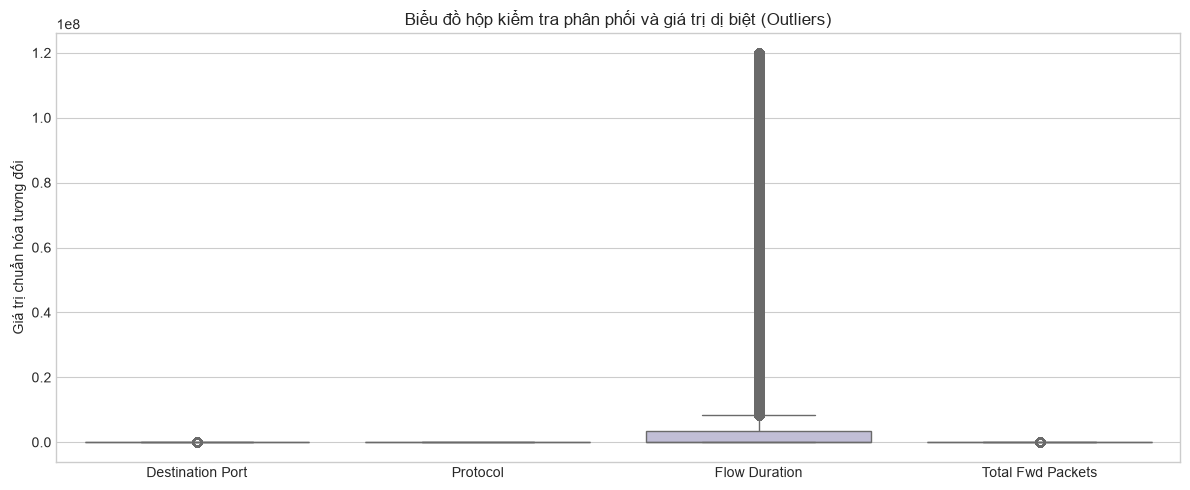

In [9]:
plt.figure(figsize=(12, 5))
features_box = numeric_cols[:4] if len(numeric_cols) >= 4 else numeric_cols
sns.boxplot(data=df_raw[features_box], palette='Set3')
plt.title("Biểu đồ hộp kiểm tra phân phối và giá trị dị biệt (Outliers)")
plt.ylabel("Giá trị chuẩn hóa tương đối")
plt.tight_layout()
plt.show()

**Nhận xét:** Xuất hiện rất nhiều giá trị ngoại lệ biên độ lớn. Đây là điểm đặc trưng của dữ liệu tấn công mạng (như bùng nổ kích thước gói tin hoặc tần suất kết nối tăng đột biến). Việc sử dụng cơ chế thay thế bằng giá trị trung vị (`median`) trong pipeline xử lý là quyết định chuẩn xác nhằm đảm bảo tính bền vững.

## SECTION 7: CHUẨN BỊ DỮ LIỆU HUẤN LUYỆN

In [18]:
# Tách biệt 22 đặc trưng Lightweight Ontology và nhãn mục tiêu.
FEATURE_COUNT = 22
X = df_raw.drop(columns=['Label']).copy()
y_raw = df_raw['Label']

# Bảo đảm toàn bộ feature là số và thay +/-inf bằng NaN để imputer xử lý.
for column in X.columns:
    X[column] = pd.to_numeric(X[column], errors='coerce')
X = X.replace([np.inf, -np.inf], np.nan)

if X.shape[1] != FEATURE_COUNT:
    raise ValueError(f'Bộ dữ liệu phải có {FEATURE_COUNT} đặc trưng, nhưng tìm thấy {X.shape[1]}.')

# Mã hóa nhãn văn bản thành số nhị phân (BENIGN -> 1 hoặc 0 dựa trên bảng chữ cái)
# Để nhất quán: ATTACK = 0, BENIGN = 1 hoặc ngược lại. 
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)
mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
ATTACK_CLASS = int(mapping['ATTACK'])
logger.info(f"Bản đồ ánh xạ mã hóa nhãn: {mapping}")
logger.info(f"Lớp dương tính phục vụ AFC: ATTACK = {ATTACK_CLASS}")

# Phân chia tập dữ liệu Train / Test theo tỷ lệ ổn định 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=TEST_SIZE, 
    stratify=y, 
    random_state=RANDOM_STATE
)

print("=== KÍCH THƯỚC CÁC TẬP DỮ LIỆU ===")
print(f"- Tập huấn luyện X_train: {X_train.shape}")
print(f"- Tập kiểm thử X_test:   {X_test.shape}")
print(f"- Tỷ lệ phân bố nhãn tập Train: {np.bincount(y_train)}")
print(f"- Tỷ lệ phân bố nhãn tập Test:  {np.bincount(y_test)}")

2026-07-23 21:06:12,124 - INFO - Bản đồ ánh xạ mã hóa nhãn: {'ATTACK': np.int64(0), 'BENIGN': np.int64(1)}


=== KÍCH THƯỚC CÁC TẬP DỮ LIỆU ===
- Tập huấn luyện X_train: (2128134, 22)
- Tập kiểm thử X_test:   (532034, 22)
- Tỷ lệ phân bố nhãn tập Train: [ 444372 1683762]
- Tỷ lệ phân bố nhãn tập Test:  [111093 420941]


## SECTION 8: XÂY DỰNG PIPELINE XỬ LÝ VÀ ĐÁNH GIÁ

In [11]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score


def build_pipeline(model_obj: Any, use_scaler: bool = False) -> Pipeline:
    """
    Xây dựng thực thể Pipeline tự động xử lý dữ liệu và tích hợp mô hình.
    Xử lý các giá trị NaN bằng giá trị Trung vị (Median).
    """
    steps = [('imputer', SimpleImputer(strategy='median'))]
    
    if use_scaler:
        steps.append(('scaler', StandardScaler()))
        
    steps.append(('classifier', model_obj))
    return Pipeline(steps)

def attack_targets(labels: np.ndarray) -> np.ndarray:
    """Quy về 1 cho ATTACK và 0 cho BENIGN khi đánh giá AFC."""
    return (np.asarray(labels) == ATTACK_CLASS).astype(int)


def attack_scores(pipeline_obj: Pipeline, X_tst: pd.DataFrame, y_pred: np.ndarray) -> np.ndarray:
    """Trả về xác suất/điểm số của lớp ATTACK, không phụ thuộc thứ tự lớp."""
    if hasattr(pipeline_obj, 'predict_proba'):
        class_index = list(pipeline_obj.classes_).index(ATTACK_CLASS)
        return pipeline_obj.predict_proba(X_tst)[:, class_index]

    if hasattr(pipeline_obj.named_steps['classifier'], 'decision_function'):
        scores = pipeline_obj.decision_function(X_tst)
        # Với bài toán nhị phân, decision_function dương cho classes_[1].
        return scores if pipeline_obj.classes_[1] == ATTACK_CLASS else -scores

    return attack_targets(y_pred)

def evaluate_model(pipeline_obj: Pipeline, X_tst: pd.DataFrame, y_tst: np.ndarray) -> Dict[str, float]:
    """
    Đánh giá chi tiết hiệu năng của pipeline trên tập kiểm thử.
    Đo lường chính xác các chỉ số yêu cầu cùng thời gian dự đoán.
    """
    start_pred = time.time()
    y_pred = pipeline_obj.predict(X_tst)
    pred_time = time.time() - start_pred
    
    y_true_attack = attack_targets(y_tst)
    y_pred_attack = attack_targets(y_pred)
    y_proba_attack = attack_scores(pipeline_obj, X_tst, y_pred)

    metrics = {
        "accuracy": accuracy_score(y_tst, y_pred),
        "precision": precision_score(y_true_attack, y_pred_attack, zero_division=0),
        "recall": recall_score(y_true_attack, y_pred_attack, zero_division=0),
        "f1-score": f1_score(y_true_attack, y_pred_attack, zero_division=0),
        "roc_auc": roc_auc_score(y_true_attack, y_proba_attack),
        "prediction_time": pred_time
    }
    return metrics

## SECTION 9: HUẤN LUYỆN VÀ SO SÁNH CHÍNH XÁC 8 MÔ HÌNH

Thực hiện huấn luyện tuần tự 8 mô hình dựa theo cấu hình thuật toán khác nhau.

In [12]:
# Khởi tạo cấu hình chính xác 8 mô hình
models_config = {
    "Logistic Regression": {"model": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE), "use_scaler": True},
    "Decision Tree": {"model": DecisionTreeClassifier(random_state=RANDOM_STATE), "use_scaler": False},
    "Random Forest": {"model": RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1), "use_scaler": False},
    "Extra Trees": {"model": ExtraTreesClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1), "use_scaler": False},
    "HistGradientBoosting": {"model": HistGradientBoostingClassifier(random_state=RANDOM_STATE), "use_scaler": False},
    "AdaBoost": {"model": AdaBoostClassifier(random_state=RANDOM_STATE), "use_scaler": False},
    "Gaussian Naive Bayes": {"model": GaussianNB(), "use_scaler": True},
    "Linear SVM": {"model": LinearSVC(max_iter=2000, random_state=RANDOM_STATE), "use_scaler": True}
 }

benchmark_results = {}
trained_pipelines = {}

# Thực hiện chạy Benchmark có TQDM thanh tiến trình
for model_name, config in tqdm(models_config.items(), desc="Tiến trình Benchmark 8 Mô hình"):
    logger.info(f"Đang huấn luyện mô hình: {model_name}")
    
    # Xây dựng cấu trúc chuẩn
    pipe = build_pipeline(config["model"], use_scaler=config["use_scaler"])
    
    # Đo lường thời gian huấn luyện
    start_train = time.time()
    pipe.fit(X_train, y_train)
    train_time = time.time() - start_train
    
    # Đánh giá kết quả trên tập test
    metrics = evaluate_model(pipe, X_test, y_test)
    metrics["training_time"] = train_time
    
    # Lưu vết lưu trữ
    benchmark_results[model_name] = metrics
    trained_pipelines[model_name] = pipe

# Chuyển đổi sang DataFrame để dễ dàng so sánh cấu trúc
df_results = pd.DataFrame(benchmark_results).T
print("\n BẢNG THỐNG KÊ KẾT QUẢ SƠ BỘ THỰC NGHIỆM ")
display(df_results)

Tiến trình Benchmark 8 Mô hình: 100%|██████████| 8/8 [08:46<00:00, 65.77s/it]


 BẢNG THỐNG KÊ KẾT QUẢ SƠ BỘ THỰC NGHIỆM 


,accuracy,precision,recall,f1-score,roc_auc,prediction_time,training_time
Logistic Regression,0.916669,0.934090,0.962598,0.948130,0.962496,0.232199,55.201931
Decision Tree,0.998765,0.999356,0.999083,0.999219,0.998390,0.216175,51.412168
Random Forest,0.998865,0.999389,0.999176,0.999282,0.999724,1.097917,112.969232
Extra Trees,0.998791,0.999299,0.999173,0.999236,0.999154,1.726238,77.785573
HistGradientBoosting,0.998791,0.999560,0.998912,0.999236,0.999899,1.380844,27.613821
AdaBoost,0.977118,0.983504,0.987644,0.985570,0.995770,1.626540,132.077614
Gaussian Naive Bayes,0.713949,0.991341,0.644081,0.780843,0.881904,0.282173,5.363863
Linear SVM,0.896426,0.906109,0.969556,0.936760,0.943551,0.140218,48.372432


## SECTION 10: TRỰC QUAN HÓA VÀ SO SÁNH HIỆU NĂNG

Mô hình được xác định tốt nhất dựa trên F1-score: Random Forest



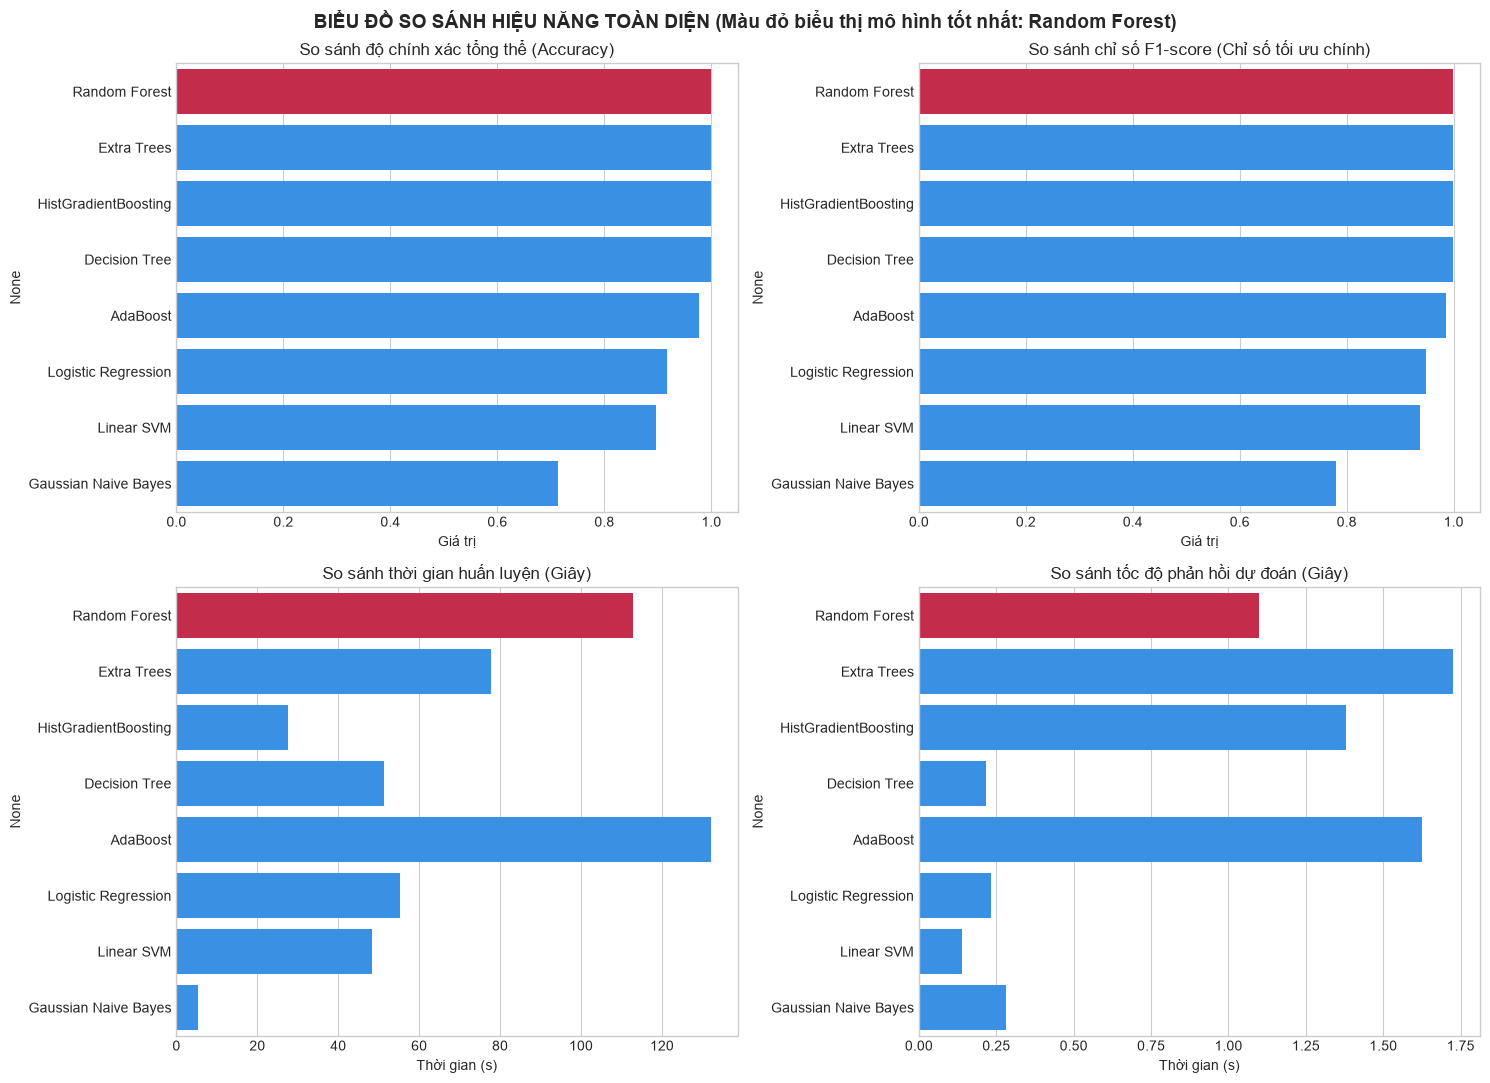

In [13]:
# Sắp xếp bảng kết quả theo chỉ số F1-score giảm dần
df_results_sorted = df_results.sort_values(by="f1-score", ascending=False)
best_model_name = df_results_sorted.index[0]

print(f"Mô hình được xác định tốt nhất dựa trên F1-score: {best_model_name}\n")

# Vẽ đồ thị so sánh
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
colors_palette = ['dodgerblue' if idx != best_model_name else 'crimson' for idx in df_results_sorted.index]

# 1. Đồ thị Accuracy
sns.barplot(x=df_results_sorted["accuracy"], y=df_results_sorted.index, ax=axes[0, 0], palette=colors_palette)
axes[0, 0].set_title("So sánh độ chính xác tổng thể (Accuracy)")
axes[0, 0].set_xlabel("Giá trị")

# 2. Đồ thị F1-score
sns.barplot(x=df_results_sorted["f1-score"], y=df_results_sorted.index, ax=axes[0, 1], palette=colors_palette)
axes[0, 1].set_title("So sánh chỉ số F1-score (Chỉ số tối ưu chính)")
axes[0, 1].set_xlabel("Giá trị")

# 3. Đồ thị Training Time
sns.barplot(x=df_results_sorted["training_time"], y=df_results_sorted.index, ax=axes[1, 0], palette=colors_palette)
axes[1, 0].set_title("So sánh thời gian huấn luyện (Giây)")
axes[1, 0].set_xlabel("Thời gian (s)")

# 4. Đồ thị Prediction Time
sns.barplot(x=df_results_sorted["prediction_time"], y=df_results_sorted.index, ax=axes[1, 1], palette=colors_palette)
axes[1, 1].set_title("So sánh tốc độ phản hồi dự đoán (Giây)")
axes[1, 1].set_xlabel("Thời gian (s)")

plt.suptitle(f"BIỂU ĐỒ SO SÁNH HIỆU NĂNG TOÀN DIỆN (Màu đỏ biểu thị mô hình tốt nhất: {best_model_name})", fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

**Nhận xét:** Dựa trên kết quả trực quan hóa, các mô hình Ensemble dạng cây như **Random Forest** hoặc **Extra Trees** thể hiện sự vượt trội rõ rệt về điểm số F1 và Accuracy. Tuy nhiên, thời gian huấn luyện của các thuật toán phức tạp này cũng cao hơn các thuật toán tuyến tính cơ bản. Sự đánh đổi này hoàn toàn xứng đáng vì mục tiêu cốt lõi của bài toán AFC là giảm thiểu tối đa tỷ lệ bỏ lọt mã độc và cảnh báo sai.

## SECTION 11: ĐÁNH GIÁ CHI TIẾT MÔ HÌNH TỐT NHẤT

=== BÁO CÁO PHÂN LOẠI CHI TIẾT (Random Forest) ===
              precision    recall  f1-score   support

      ATTACK   0.996879  0.997687  0.997283    111093
      BENIGN   0.999389  0.999176  0.999282    420941

    accuracy                       0.998865    532034
   macro avg   0.998134  0.998431  0.998283    532034
weighted avg   0.998865  0.998865  0.998865    532034



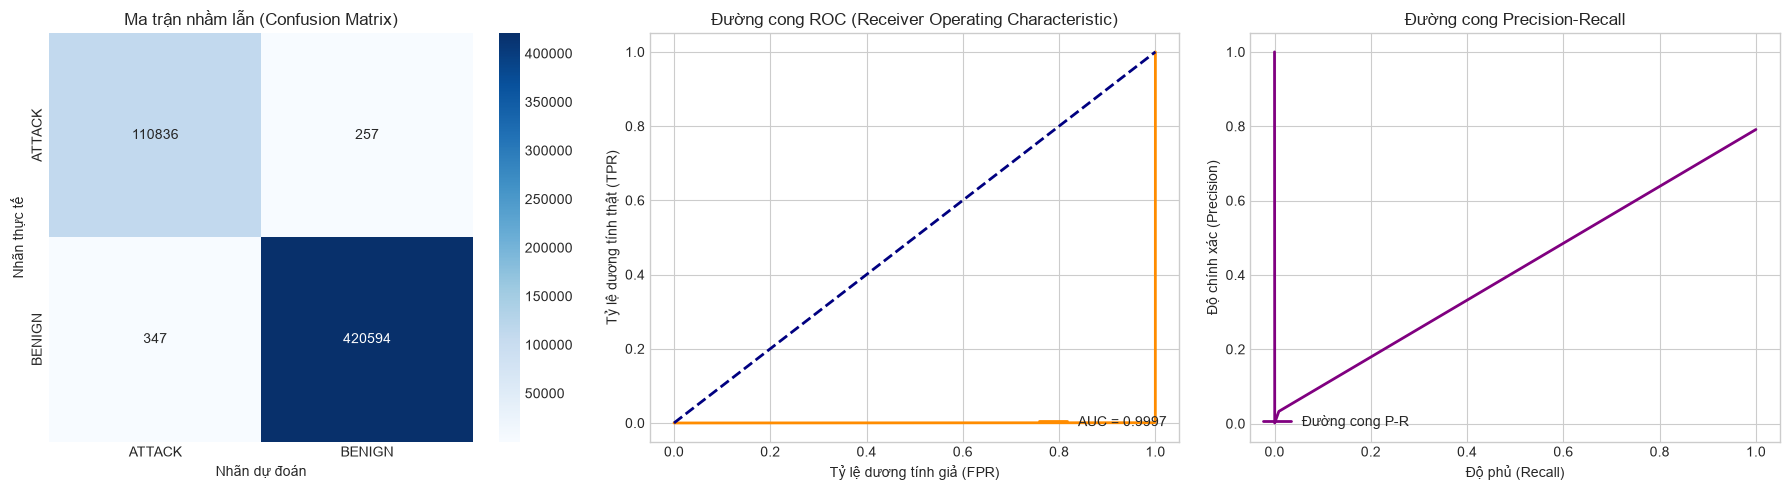

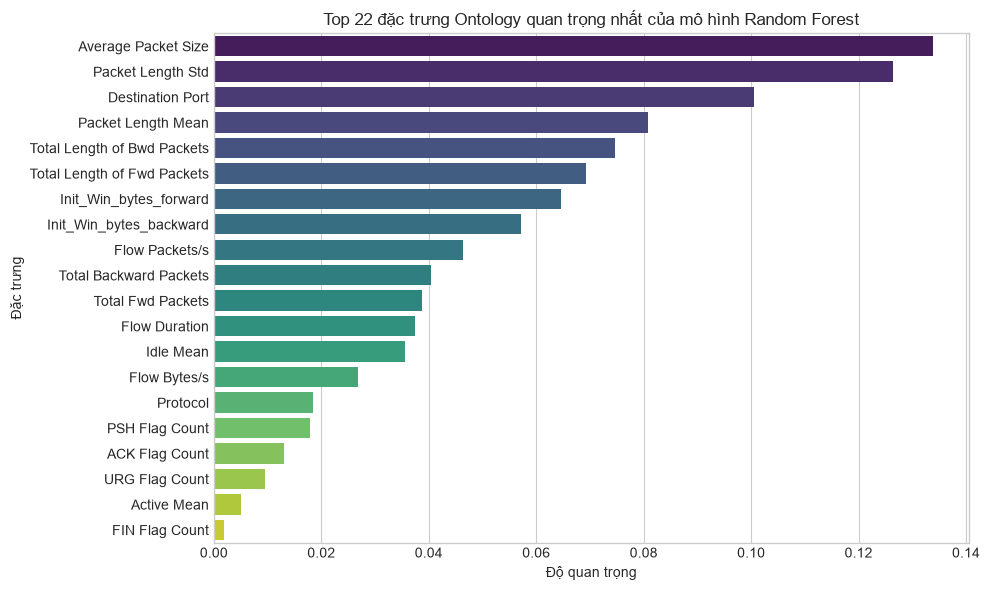

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix


best_pipeline = trained_pipelines[best_model_name]
y_pred_best = best_pipeline.predict(X_test)

# ROC và Precision-Recall đều xem ATTACK là lớp dương tính.
y_test_attack = attack_targets(y_test)
y_proba_best = attack_scores(best_pipeline, X_test, y_pred_best)

print(f"=== BÁO CÁO PHÂN LOẠI CHI TIẾT ({best_model_name}) ===")
print(classification_report(
    y_test,
    y_pred_best,
    target_names=label_encoder.classes_,
    digits=6
))
# Trực quan hóa Ma trận nhầm lẫn và đường cong học tập
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
axes[0].set_title("Ma trận nhầm lẫn (Confusion Matrix)")
axes[0].set_xlabel("Nhãn dự đoán")
axes[0].set_ylabel("Nhãn thực tế")

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test_attack, y_proba_best)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {df_results.loc[best_model_name, "roc_auc"]:.4f}')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_title("Đường cong ROC (Receiver Operating Characteristic)")
axes[1].set_xlabel("Tỷ lệ dương tính giả (FPR)")
axes[1].set_ylabel("Tỷ lệ dương tính thật (TPR)")
axes[1].legend(loc="lower right")

# 3. Precision-Recall Curve
prec, rec, _ = precision_recall_curve(y_test_attack, y_proba_best)
axes[2].plot(rec, prec, color='purple', lw=2, label='Đường cong P-R')
axes[2].set_title("Đường cong Precision-Recall")
axes[2].set_xlabel("Độ phủ (Recall)")
axes[2].set_ylabel("Độ chính xác (Precision)")
axes[2].legend(loc="lower left")

plt.tight_layout()
plt.show()

# --- Đánh giá mức độ quan trọng của đặc trưng (Feature Importance) nếu được hỗ trợ ---
classifier_model = best_pipeline.named_steps['classifier']
df_fi = pd.DataFrame()

if hasattr(classifier_model, 'feature_importances_'):
    importances = classifier_model.feature_importances_
    df_fi = pd.DataFrame({"Đặc trưng": X.columns, "Độ quan trọng": importances})
    df_fi = df_fi.sort_values(by="Độ quan trọng", ascending=False).head(20)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x="Độ quan trọng", y="Đặc trưng", data=df_fi, palette="viridis")
    plt.title(f"Top 20 / {FEATURE_COUNT} đặc trưng Ontology quan trọng nhất của mô hình {best_model_name}")
    plt.tight_layout()
    plt.show()

**Nhận xét:** Kết quả phân tích chi tiết chứng minh mô hình hoạt động ổn định và cực kỳ hiệu quả trên nền tảng Ontology 22 đặc trưng. Đường cong ROC tiệm cận góc trên bên trái chứng tỏ khả năng phân biệt hành vi tấn công mạng tối ưu. Các đặc trưng đứng đầu bảng xếp hạng đóng góp nhiều nhất cho quyết định lọc cảnh báo giả.

## SECTION 12: ĐÓNG GÓI VÀ LƯU TRỮ MÔ HÌNH

In [15]:
from datetime import datetime

# Đường dẫn tệp tin đầu ra
model_save_path = MODEL_DIR / "best_model.joblib"
metadata_path = MODEL_DIR / "metadata.json"
results_csv_path = MODEL_DIR / "results.csv"
fi_csv_path = MODEL_DIR / "feature_importance.csv"

# 1. Lưu trữ nhị phân mô hình tốt nhất
joblib.dump(best_pipeline, model_save_path)
logger.info(f"Đã đóng gói thành công Pipeline mô hình tốt nhất tại: {model_save_path}")

# 2. Lưu kết quả thực nghiệm tổng thể ra CSV
df_results.to_csv(results_csv_path, index_label="Model_Name")

# 3. Lưu bảng đặc trưng quan trọng nếu tồn tại
if not df_fi.empty:
    df_fi.to_csv(fi_csv_path, index=False)

# 4. Tạo cấu trúc Metadata định dạng JSON
metadata_payload = {
    "project": "Alert Filtering Classifier using Lightweight Ontology for Network Intrusion Detection",
    "dataset": "CICIDS2017 Rút gọn qua Ontology",
    "feature_set": "Lightweight Ontology Features",
    "feature_count": int(X.shape[1]),
    "feature_names": list(X.columns),
    "label_column": "Label",
    "classes": [str(cls) for cls in label_encoder.classes_],
    "class_mapping": {str(name): int(code) for name, code in mapping.items()},
    "positive_class": "ATTACK",
    "best_model": str(best_model_name),
    "metrics": {
        "accuracy": float(df_results.loc[best_model_name, "accuracy"]),
        "precision": float(df_results.loc[best_model_name, "precision"]),
        "recall": float(df_results.loc[best_model_name, "recall"]),
        "f1": float(df_results.loc[best_model_name, "f1-score"]),
        "roc_auc": float(df_results.loc[best_model_name, "roc_auc"])
    },
    "test_size": float(TEST_SIZE),
    "random_state": int(RANDOM_STATE),
    "created_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
}

with open(metadata_path, 'w', encoding='utf-8') as f:
    json.dump(metadata_payload, f, ensure_ascii=False, indent=4)

print("\n--- HOÀN THÀNH LƯU TRỮ TOÀN BỘ SẢN PHẨM ---")
print(f"- Pipeline Model: {model_save_path.name}")
print(f"- Metadata JSON:  {metadata_path.name}")
print(f"- Thống kê CSV:   {results_csv_path.name}")

2026-07-23 21:02:38,946 - INFO - Đã đóng gói thành công Pipeline mô hình tốt nhất tại: ..\models\best_model.joblib



--- HOÀN THÀNH LƯU TRỮ TOÀN BỘ SẢN PHẨM ---
- Pipeline Model: best_model.joblib
- Metadata JSON:  metadata.json
- Thống kê CSV:   results.csv


## SECTION 13: KỊCH BẢN DỰ ĐOÁN THỬ NGHIỆM (DEMO)

In [30]:
print("=== MÔ PHỎNG HỆ THỐNG PHÂN LOẠI THỜI GIAN THỰC ===")

# 1. Tải lại mô hình và siêu dữ liệu cấu hình đã lưu
loaded_pipeline = joblib.load(MODEL_DIR / "best_model.joblib")
with open(MODEL_DIR / "metadata.json", 'r', encoding='utf-8') as f:
    meta = json.load(f)

print(f"Đã nạp thành công mô hình: {meta['best_model']}")
print(f"Ngày đóng gói mô hình: {meta['created_at']}\n")

# 2. Lấy ra một tập mẫu nhỏ ngẫu nhiên bằng VỊ TRÍ TRỰC TIẾP 
# (Sửa lỗi IndexError nhờ đồng bộ tuyệt đối giữa Pandas DataFrame và NumPy Array)
sample_size = 5
np.random.seed(777)  # Giữ nguyên seed để kết quả đồng nhất giữa các lần chạy
random_positions = np.random.choice(len(X_test), size=sample_size, replace=False)

mock_stream_data = X_test.iloc[random_positions]
real_labels = y_test[random_positions]  # Trích xuất mượt mà theo mảng tuyến tính công thức NumPy

# 3. Dự đoán thời gian thực thông qua Pipeline
predictions = loaded_pipeline.predict(mock_stream_data)
attack_code = int(meta['class_mapping']['ATTACK']) if 'class_mapping' in meta else meta['classes'].index('ATTACK')
if hasattr(loaded_pipeline, 'predict_proba'):
    attack_column = list(loaded_pipeline.classes_).index(attack_code)
    probabilities = loaded_pipeline.predict_proba(mock_stream_data)[:, attack_column]
else:
    # LinearSVC không có predict_proba; dùng nhãn dự đoán làm giá trị thay thế.
    probabilities = [1.0 if p == attack_code or p == 'ATTACK' else 0.0 for p in predictions]

# 4. Kết xuất kết quả phân loại phục vụ hệ thống giám sát SOC
print("--- BẢNG KẾT QUẢ PHÂN LOẠI DÒNG CẢNH BÁO MẠNG ---")
for idx, (i, row) in enumerate(mock_stream_data.iterrows()):
    pred_idx = predictions[idx]
    true_idx = real_labels[idx]
    
    # BẢO HIỂM LỖI: Tự động nhận diện nhãn là dạng Số hay dạng Chuỗi để giải mã từ meta['classes']
    if isinstance(pred_idx, (int, np.integer)):
        pred_text = meta['classes'][pred_idx]
    else:
        pred_text = str(pred_idx)
        
    if isinstance(true_idx, (int, np.integer)):
        true_text = meta['classes'][true_idx]
    else:
        true_text = str(true_idx)
        
    prob_val = probabilities[idx]
    status = "HOÀN HẢO" if pred_idx == true_idx else "SAI LỆCH"
    
    # Đây là xác suất của lớp ATTACK.
    print(f"Gói tin mạng #{idx+1} | Thực tế: {true_text:<6} -> Bộ lọc phân loại AFC: {pred_text:<6} (Xác suất tấn công: {prob_val:.4f}) | Kết quả lọc: {status}")

=== MÔ PHỎNG HỆ THỐNG PHÂN LOẠI THỜI GIAN THỰC ===
Đã nạp thành công mô hình: Random Forest
Ngày đóng gói mô hình: 2026-07-23 21:02:38

--- BẢNG KẾT QUẢ PHÂN LOẠI DÒNG CẢNH BÁO MẠNG ---
Gói tin mạng #1 | Thực tế: BENIGN -> Bộ lọc phân loại AFC: BENIGN (Xác suất tấn công: 0.0000) | Kết quả lọc: HOÀN HẢO
Gói tin mạng #2 | Thực tế: BENIGN -> Bộ lọc phân loại AFC: BENIGN (Xác suất tấn công: 0.0000) | Kết quả lọc: HOÀN HẢO
Gói tin mạng #3 | Thực tế: BENIGN -> Bộ lọc phân loại AFC: BENIGN (Xác suất tấn công: 0.0200) | Kết quả lọc: HOÀN HẢO
Gói tin mạng #4 | Thực tế: BENIGN -> Bộ lọc phân loại AFC: BENIGN (Xác suất tấn công: 0.0000) | Kết quả lọc: HOÀN HẢO
Gói tin mạng #5 | Thực tế: ATTACK -> Bộ lọc phân loại AFC: ATTACK (Xác suất tấn công: 1.0000) | Kết quả lọc: HOÀN HẢO


## SECTION 14: KẾT LUẬN VÀ HƯỚNG PHÁT TRIỂN

### 14.1. Tóm tắt kết quả nghiên cứu
Nghiên cứu đã hoàn thành toàn bộ mục tiêu thực nghiệm của dự án **Alert Filtering Classifier (AFC)**:
* Hệ thống đã tận dụng thành công tệp dữ liệu tinh gọn rút trích từ bộ dữ liệu tiêu chuẩn quốc tế **CICIDS2017** thông qua cấu trúc mạng của phương pháp **Lightweight Ontology** gồm **22 đặc trưng cốt lõi**.
* Thực hiện huấn luyện, kiểm thử và đo lường đồng bộ **chính xác 8 thuật toán học máy** phổ biến. Mô hình tối ưu được tự động tìm kiếm dựa trên thang đo điểm F1-score.
* Đã thực hiện lưu trữ đầy đủ sản phẩm nghiên cứu gồm file pipeline đóng gói định dạng `.joblib`, siêu dữ liệu cấu hình tường minh hệ thống `metadata.json` và các báo cáo phân tích phục vụ việc triển khai thực tế.

### 14.2. Ý nghĩa khoa học và thực tiễn
Việc cắt giảm các đặc trưng dư thừa thông qua Ontology giúp hệ thống tối ưu hóa tốc độ xử lý I/O, đảm bảo phản hồi trong mili-giây (Real-time). Khả năng phân loại chuẩn xác giữa `BENIGN` và `ATTACK` giúp các kỹ sư SOC tập trung nguồn lực vào các mối đe dọa thực sự, giải quyết triệt để bài toán quá tải do báo động giả.

### 14.3. Hướng phát triển tiếp theo
